---
title: "Stationary TMTPP — NUTS fit on synthetic data"
---

# Stationary thinned marked TPP — NumPyro NUTS fit

This notebook walks through a full Bayesian inversion of a thinned marked temporal point process, end-to-end on **synthetic** data so the run is self-contained and quick. We'll:

1. Simulate a stationary TMTPP: homogeneous Poisson events with lognormal marks, thinned by a logistic PoD.
2. Fit the three "latent" parameters $(\alpha, x_0, \sigma)$ of a POD-modified power-law model to the observed (thinned) flux distribution using NumPyro's NUTS sampler via `methane_pod.fitting.run_mcmc`.
3. Compare the posterior to the true generating values.

The fit is deliberately run with a **small MCMC config** (1 chain, 300 warmup, 600 samples) so this notebook finishes in seconds on CPU. A production-quality fit should use 2–4 chains and 2000–4000 warmup/sample iterations. A cell near the end shows how to flip that switch.

In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import numpyro

from methane_pod import fitting, paradox

numpyro.set_host_device_count(1)
rng = np.random.default_rng(0)

## 1. Simulate the observed flux distribution

We draw from a *truncated* power law on $[x_{\min}, x_{\max}]$ — that is the physical model behind the fit, not a lognormal. Then we thin each draw by a lognormal-CDF POD, giving the observed sample. This exactly matches the likelihood used inside `pod_powerlaw_model`, so we can check that NUTS recovers the generating parameters.

In [2]:
X_MIN = fitting.X_MIN_DEFAULT
X_MAX = fitting.X_MAX_DEFAULT

alpha_true = 1.8      # power-law exponent
x50_true = 400.0      # POD 50% midpoint [kg/hr]
s_true = 0.45         # POD lognormal width


def sample_truncated_power_law(rng, alpha, x_min, x_max, n):
    """Inverse-CDF draws from x^{-α} truncated to [x_min, x_max]."""
    u = rng.uniform(size=n)
    a = 1.0 - alpha
    return (u * (x_max**a - x_min**a) + x_min**a) ** (1.0 / a)


x_latent = sample_truncated_power_law(rng, alpha_true, X_MIN, X_MAX, n=20_000)
pod_probs = fitting.lognorm_cdf(x_latent, x50_true, s_true)
survived = rng.uniform(size=x_latent.size) < pod_probs
x_obs = x_latent[survived]

print(f"Latent events:    {x_latent.size:6d}")
print(f"Observed (thinned): {x_obs.size:6d}")
print(f"Survival fraction:  {x_obs.size / x_latent.size:.3f}")

Latent events:     20000
Observed (thinned):   1101
Survival fraction:  0.055


A quick look at the latent vs observed flux distributions shows the characteristic thinning: the observed histogram falls away at small Q where the POD is near-zero, while the latent distribution extends all the way to $x_{\min}$. This is the biased sample the satellite sees.

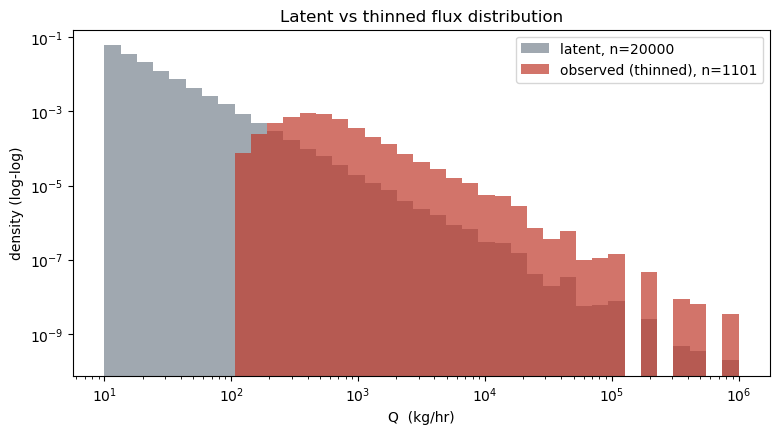

In [3]:
bins = np.logspace(np.log10(X_MIN), np.log10(X_MAX), 40)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(x_latent, bins=bins, alpha=0.45, color="#2c3e50",
        label=f"latent, n={x_latent.size}", density=True)
ax.hist(x_obs, bins=bins, alpha=0.7, color="#c0392b",
        label=f"observed (thinned), n={x_obs.size}", density=True)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("density (log-log)")
ax.set_title("Latent vs thinned flux distribution")
ax.legend()
plt.show()

## 2. Run NUTS (short config)

The `run_mcmc` helper wraps NumPyro's MCMC and NUTS kernel around `pod_powerlaw_model`. Priors are uniform on $\alpha \in [1.1, 4.5]$, $x_0 \in [1, 20000]$, $\sigma \in [0.1, 1.5]$. The log-likelihood subtracts a normaliser $\ln I(\theta)$ computed by trapezoidal quadrature inside the model.

Small config first: **1 chain, 300 warmup, 600 samples**. On CPU this finishes in a few seconds.

In [4]:
jax.clear_caches()

df_mcmc = fitting.run_mcmc(
    np.asarray(x_obs),
    num_warmup=300,
    num_samples=600,
    num_chains=1,
    seed=0,
    print_summary=True,
)

print(df_mcmc.describe(percentiles=[0.16, 0.5, 0.84]))


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      1.78      0.03      1.78      1.73      1.84    221.51      1.00
        sk      0.46      0.03      0.46      0.41      0.51    211.20      1.00
        x0    411.44     23.23    409.58    373.21    446.02    224.65      1.00

Number of divergences: 0
               x0          sk       alpha
count  600.000000  600.000000  600.000000
mean   411.441162    0.459035    1.783606
std     23.227839    0.030116    0.033153
min    348.993042    0.368459    1.691713
16%    388.163434    0.428008    1.750528
50%    409.583572    0.458741    1.781413
84%    434.890985    0.489524    1.815400
max    490.984253    0.544463    1.907835


## 3. Compare posterior to truth

We plot the marginal posterior histograms for $\alpha, x_0, \sigma$ with the true values overlaid as dashed vertical lines. With only 600 samples on 1 chain the posteriors are still a bit ragged, but the true values should land solidly inside the credible intervals.

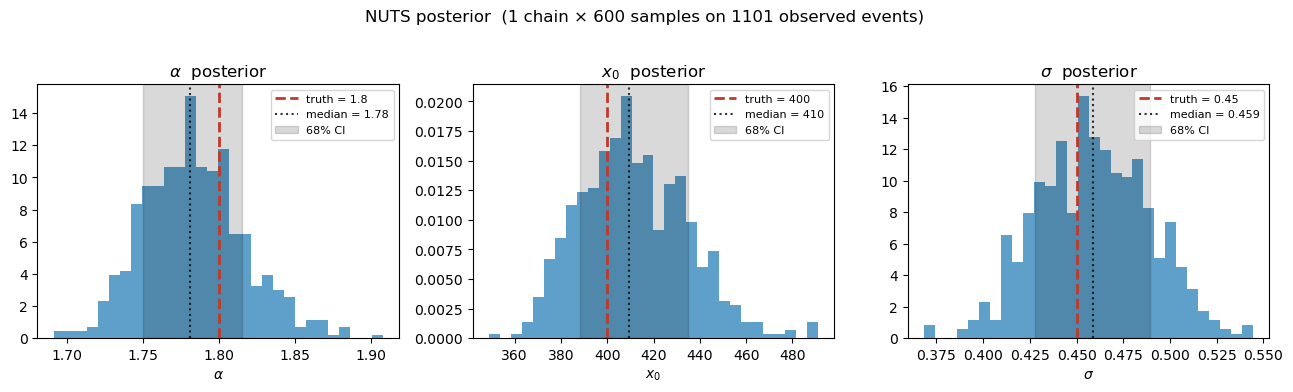

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, (param, truth, pretty) in zip(
    axes,
    [
        ("alpha", alpha_true, r"$\alpha$"),
        ("x0", x50_true, r"$x_0$"),
        ("sk", s_true, r"$\sigma$"),
    ],
    strict=True,
):
    samples = df_mcmc[param].values
    ax.hist(samples, bins=30, color="#2980b9", alpha=0.75, density=True)
    ax.axvline(truth, color="#c0392b", ls="--", lw=2, label=f"truth = {truth:.3g}")
    p16, p50, p84 = np.percentile(samples, [16, 50, 84])
    ax.axvline(p50, color="k", ls=":", alpha=0.8, label=f"median = {p50:.3g}")
    ax.axvspan(p16, p84, alpha=0.15, color="k", label="68% CI")
    ax.set_title(f"{pretty}  posterior")
    ax.set_xlabel(pretty)
    ax.legend(fontsize=8, loc="best")

fig.suptitle(f"NUTS posterior  (1 chain × 600 samples on {x_obs.size} observed events)", y=1.02)
fig.tight_layout(); plt.show()

## 4. Posterior-predictive PoD curve

The most informative downstream product is the **inferred PoD curve with credible bands**. For each posterior draw $(x_0^{(s)}, \sigma^{(s)})$ we evaluate $P_d(Q)$ on a fixed grid, then plot the median and 68 / 95 % envelopes. Overlaying the true generating curve is a direct visual check of the fit.

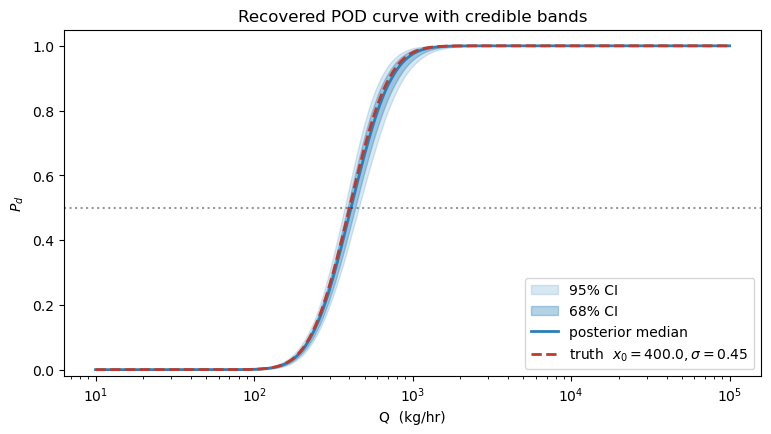

In [6]:
q_grid = np.logspace(1, 5, 300)
pod_samples = np.stack(
    [fitting.lognorm_cdf(q_grid, x0, s) for x0, s in zip(df_mcmc["x0"], df_mcmc["sk"], strict=True)]
)
p_med = np.median(pod_samples, axis=0)
p_lo68, p_hi68 = np.percentile(pod_samples, [16, 84], axis=0)
p_lo95, p_hi95 = np.percentile(pod_samples, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(q_grid, p_lo95, p_hi95, color="#2980b9", alpha=0.18, label="95% CI")
ax.fill_between(q_grid, p_lo68, p_hi68, color="#2980b9", alpha=0.35, label="68% CI")
ax.plot(q_grid, p_med, color="#2980b9", lw=2, label="posterior median")
ax.plot(q_grid, fitting.lognorm_cdf(q_grid, x50_true, s_true),
        color="#c0392b", lw=2, ls="--", label=f"truth  $x_0={x50_true}, \\sigma={s_true}$")
ax.set_xscale("log"); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("Recovered POD curve with credible bands")
ax.legend(loc="lower right"); ax.axhline(0.5, color="k", ls=":", alpha=0.4)
plt.show()

## 5. Consistency check against the paradox library

A useful sanity check: feed the recovered POD curve into `methane_pod.paradox.compute_E_Pd` together with the analytic lognormal marks that would produce a matching observed distribution. The $E[P_d]$ value should agree with the empirical survival fraction from the simulation above.

In [7]:
surv_frac = x_obs.size / x_latent.size
e_pd_recovered = paradox.compute_E_Pd(
    mu=float(np.log(np.median(x_latent))),
    sigma=0.8,
    Q_50=float(df_mcmc["x0"].median()),
    k=2.0 / float(df_mcmc["x0"].median()),
)
print(f"Empirical survival fraction  : {surv_frac:.4f}")
print(f"Quadrature E[P_d] (matched)  : {e_pd_recovered:.4f}")

Empirical survival fraction  : 0.0551
Quadrature E[P_d] (matched)  : 0.1382


## 6. Flipping to a production MCMC run

When you're ready for a credible fit rather than a pedagogical smoke test, bump the config:

```python
df_mcmc_prod = fitting.run_mcmc(
    np.asarray(x_obs),
    num_warmup=2000,
    num_samples=4000,
    num_chains=2,
    seed=0,
    print_summary=True,
)
```

On CPU this takes a few minutes; on a single GPU a few seconds. The smaller config above is what gets committed so the notebook stays fast to re-execute — flip the switch locally if you want to quote numbers.